In [1]:
import pandas as pd
import json
from pathlib import Path

SPLIT_DIR = Path("../data/processed/02_split")       # output từ notebook 02
PROCESSED_DIR = Path("../data/processed/03_distribution")

# ============================================================
# Đọc train thật (từ Giai đoạn 2) — TUYỆT ĐỐI không đọc file test
# ============================================================
df_train = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
print(f"Số dòng train dùng để học phân phối: {len(df_train)}")

# ============================================================
# Bảng ánh xạ Tên ngành -> Mã ngành (theo ảnh 1 đã đối chiếu)
# ============================================================
ten_to_ma = {
    "Quản trị dịch vụ du lịch và lữ hành": 7810103,
    "Quản trị khách sạn": 7810201,
    "Quản trị nhà hàng và dịch vụ ăn uống": 7810202,
    "Khoa học dinh dưỡng và ẩm thực": 7819009,
    "Khoa học chế biến món ăn": 7819010,
    "Du lịch": 7810101,
    "Luật": 7380101,
    "Luật kinh tế": 7380107,
    "Ngôn ngữ Anh": 7220201,
    "Ngôn ngữ Trung Quốc": 7220204,
    "Công nghệ thông tin": 7480201,
    "An toàn thông tin": 7480202,
    "Khoa học dữ liệu": 7460108,
    "Kế toán": 7340301,
    "Tài chính ngân hàng": 7340201,
    "Công nghệ tài chính": 7340205,
    "Marketing": 7340115,
    "Thương mại điện tử": 7340122,
    "Logistics và quản lý chuỗi cung ứng": 7510605,
    "Quản trị kinh doanh": 7340101,
    "Kinh doanh quốc tế": 7340120,
    "Công nghệ dệt, may": 7540204,
    "Kinh doanh thời trang và dệt may": 7340123,
    "Công nghệ thực phẩm": 7540101,
    "Đảm bảo chất lượng và an toàn thực phẩm": 7540106,
    "Quản trị kinh doanh thực phẩm": 7340129,
    "Công nghệ chế biến thủy sản": 7540105,
    "Công nghệ chế tạo máy": 7510202,
    "Công nghệ kỹ thuật cơ điện tử": 7510203,
    "Kỹ thuật nhiệt": 7520115,
    "Công nghệ kỹ thuật điện - điện tử": 7510301,
    "Công nghệ kỹ thuật điều khiển và TĐH": 7510303,
    "Công nghệ kỹ thuật hóa học": 7510401,
    "Công nghệ vật liệu": 7510402,
    "Công nghệ sinh học": 7420201,
    "Quản lý tài nguyên và môi trường": 7850101,
    "Công nghệ kỹ thuật môi trường": 7510406,
    "Trí tuệ nhân tạo": 7480107,
    "Quản lý Công nghiệp": 7510601,
}

df_train['ma_nganh'] = df_train['nganh_hoc'].map(ten_to_ma)

# Kiểm tra map thiếu (không nên có, nhưng luôn kiểm tra để chắc)
chua_map = df_train[df_train['ma_nganh'].isna()]
if len(chua_map) > 0:
    print(f"⚠️ CẢNH BÁO: {len(chua_map)} dòng chưa map được mã ngành:")
    print(chua_map['nganh_hoc'].unique())
else:
    print("✅ Toàn bộ dòng đã map mã ngành thành công")

# ============================================================
# Danh sách 10 cột likert
# ============================================================
likert_cols = ['likert_nang_dong','likert_huong_noi','likert_sang_tao','likert_logic',
               'likert_to_mo','likert_thi_nghiem','likert_moi_truong','likert_dinh_duong',
               'likert_tranh_luan','likert_thiet_ke']

# ============================================================
# Học phân phối THEO TỪNG MÃ NGÀNH — chỉ từ train thật
# ============================================================
phan_phoi = {}

for ma, group in df_train.groupby('ma_nganh'):
    n = len(group)
    phan_phoi[int(ma)] = {
        'so_mau': n,
        'gioi_tinh_ty_le_nam': float((group['gioi_tinh'] == 'Nam').mean()),
        'likert_mean': {c: float(group[c].mean()) for c in likert_cols},
        # std=0.5 làm mặc định nếu ngành chỉ có 1 mẫu (std thật = NaN)
        'likert_std': {c: float(group[c].std()) if n > 1 and not pd.isna(group[c].std())
                       else 0.5 for c in likert_cols},
        'muc_tieu_phan_phoi': group['muc_tieu_nhan'].value_counts(normalize=True).to_dict(),
    }

# ============================================================
# Phân phối dự phòng TOÀN CỤC — dùng cho ngành nào TTTH có
# nhưng khảo sát train không hề có mẫu nào (VD 6 mã ngành hiếm)
# ============================================================
phan_phoi_global = {
    'gioi_tinh_ty_le_nam': float((df_train['gioi_tinh'] == 'Nam').mean()),
    'likert_mean': {c: float(df_train[c].mean()) for c in likert_cols},
    'likert_std': {c: float(df_train[c].std()) for c in likert_cols},
    'muc_tieu_phan_phoi': df_train['muc_tieu_nhan'].value_counts(normalize=True).to_dict(),
}

# ============================================================
# Báo cáo nhanh — ngành nào có mẫu quá ít (std không đáng tin)
# ============================================================
print(f"\nSố ngành đã học được phân phối riêng: {len(phan_phoi)}")
canh_bao = {ma: d['so_mau'] for ma, d in phan_phoi.items() if d['so_mau'] < 5}
print(f"\n⚠️ Các ngành có <5 mẫu trong train (phân phối học được kém tin cậy):")
for ma, n in sorted(canh_bao.items(), key=lambda x: x[1]):
    print(f"   Mã {ma}: {n} mẫu")

# ============================================================
# Lưu lại — output này là input trực tiếp cho Giai đoạn 4 (GA)
# ============================================================
output = {
    'theo_nganh': phan_phoi,
    'toan_cuc': phan_phoi_global,
}

with open(PROCESSED_DIR / "phan_phoi_theo_nganh.json", 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"\n✅ Đã lưu: {PROCESSED_DIR / 'phan_phoi_theo_nganh.json'}")

Số dòng train dùng để học phân phối: 651
✅ Toàn bộ dòng đã map mã ngành thành công

Số ngành đã học được phân phối riêng: 39

⚠️ Các ngành có <5 mẫu trong train (phân phối học được kém tin cậy):

✅ Đã lưu: ../data/processed/03_distribution/phan_phoi_theo_nganh.json


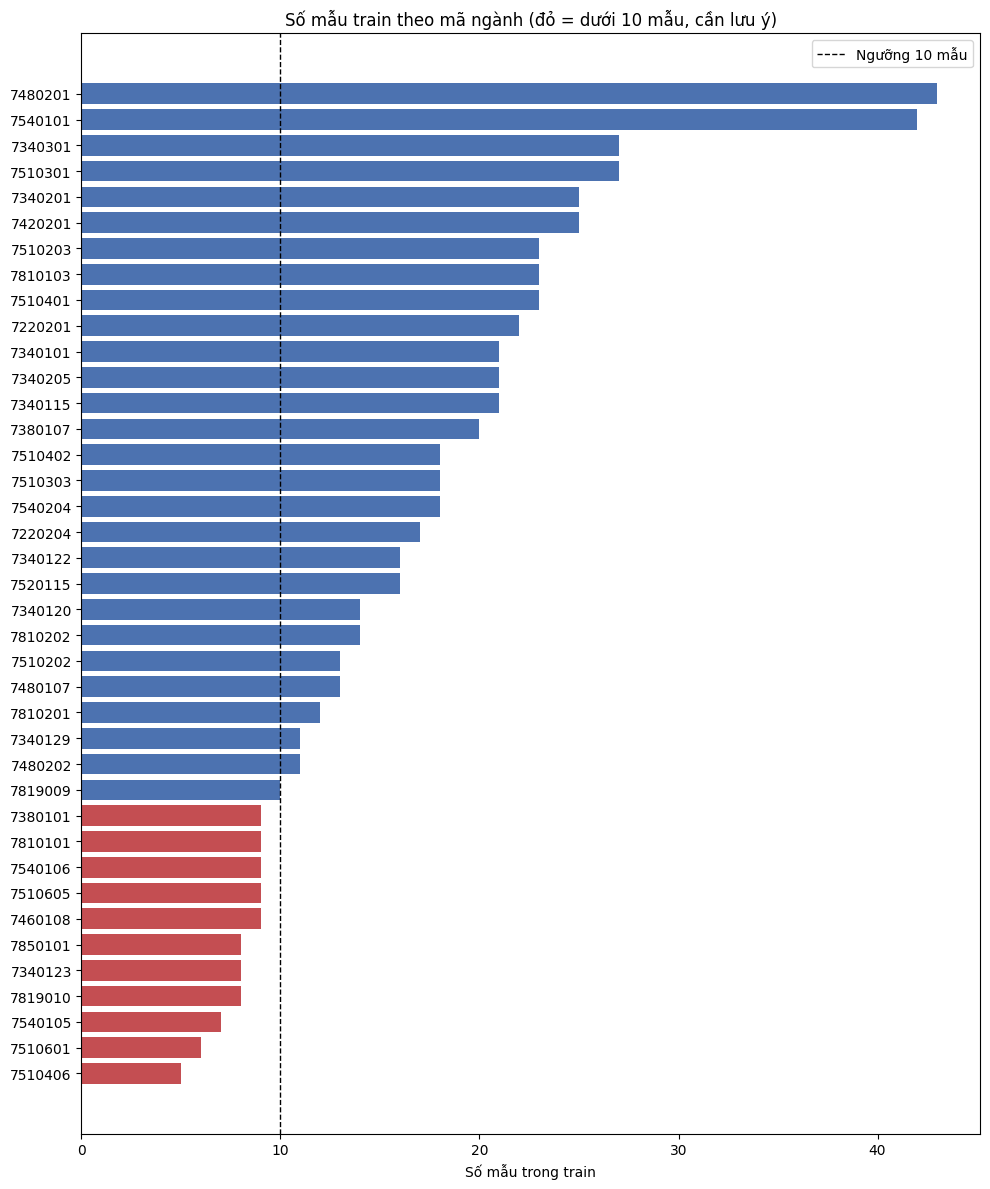

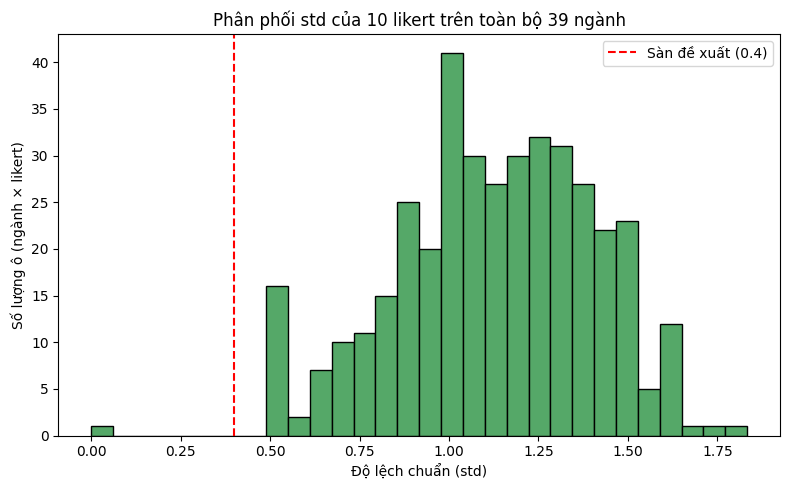


⚠️ Số ô có std < 0.4 (cần áp sàn ở Giai đoạn 4): 1 / 390


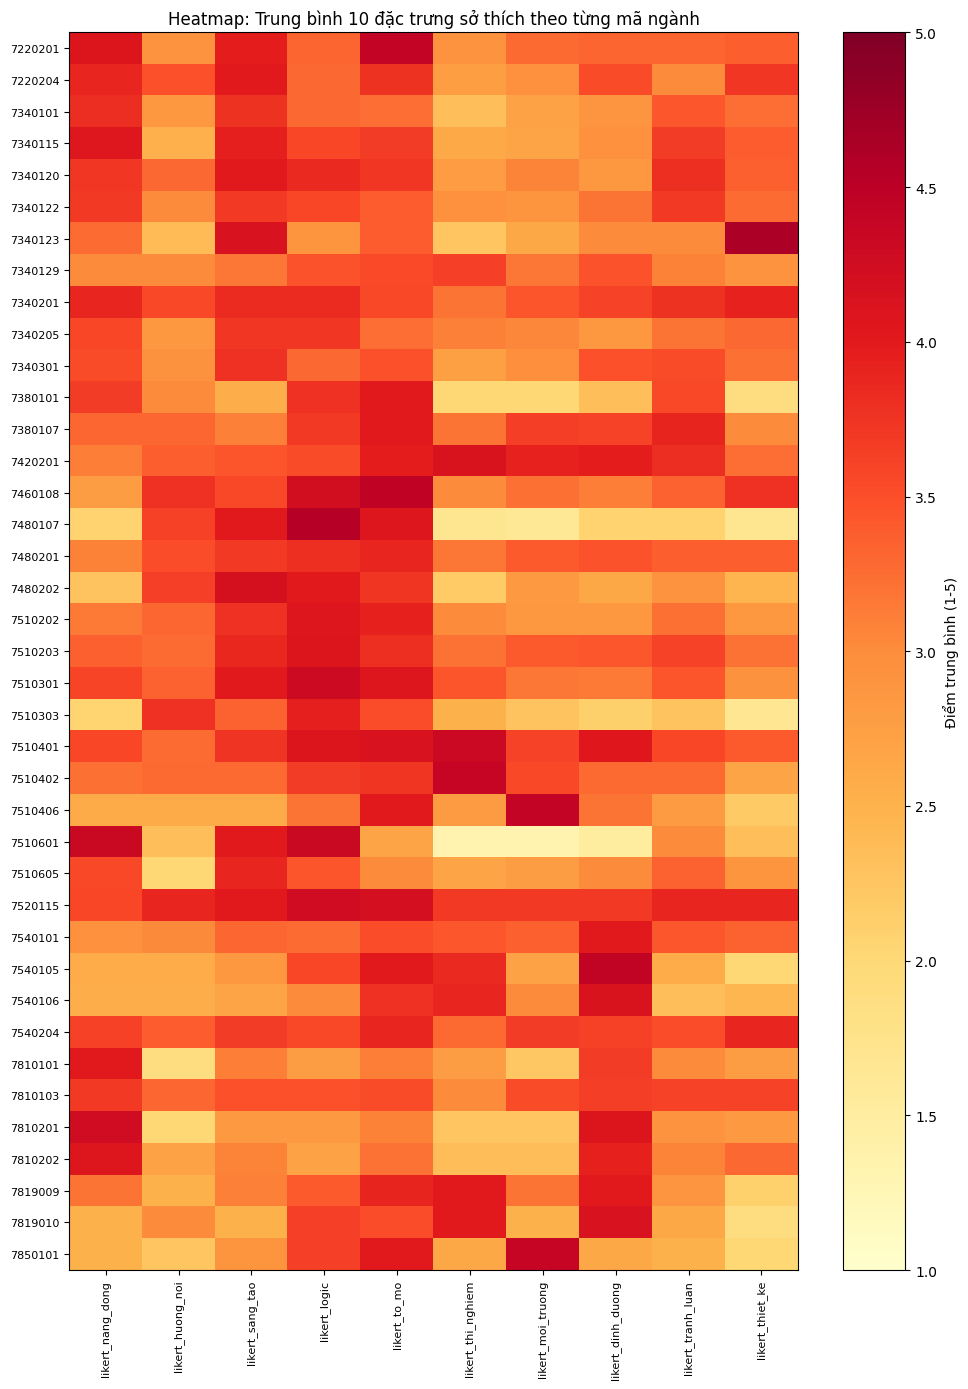

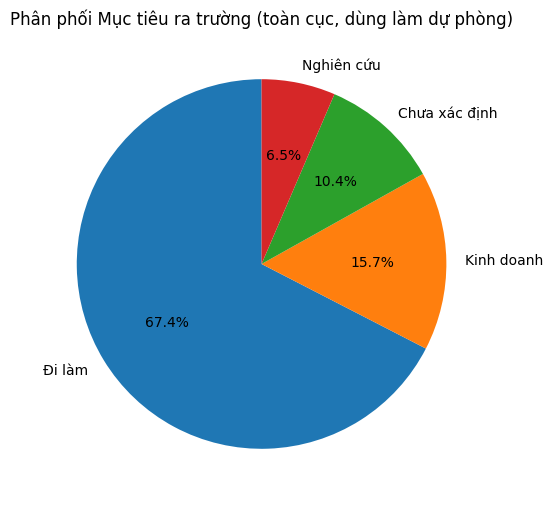

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# BIỂU ĐỒ 1 — Số mẫu train theo ngành, đánh dấu ngưỡng <10
# ============================================================
so_mau_series = pd.Series({ma: d['so_mau'] for ma, d in phan_phoi.items()}).sort_values()
colors = ['#C44E52' if v < 10 else '#4C72B0' for v in so_mau_series.values]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(so_mau_series.index.astype(str), so_mau_series.values, color=colors)
ax.axvline(10, color='black', linestyle='--', linewidth=1, label='Ngưỡng 10 mẫu')
ax.set_xlabel('Số mẫu trong train')
ax.set_title('Số mẫu train theo mã ngành (đỏ = dưới 10 mẫu, cần lưu ý)')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_so_mau_theo_nganh.png', dpi=150)
plt.show()

# ============================================================
# BIỂU ĐỒ 2 — Phân phối độ lệch chuẩn (std) của các likert theo ngành
#              để phát hiện các ô std quá thấp/bằng 0 (dữ liệu đồng nhất giả)
# ============================================================
all_std = []
for ma, d in phan_phoi.items():
    for c, v in d['likert_std'].items():
        all_std.append(v)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_std, bins=30, color='#55A868', edgecolor='black')
ax.axvline(0.4, color='red', linestyle='--', label='Sàn đề xuất (0.4)')
ax.set_xlabel('Độ lệch chuẩn (std)')
ax.set_ylabel('Số lượng ô (ngành × likert)')
ax.set_title('Phân phối std của 10 likert trên toàn bộ 39 ngành')
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bieu_do_phan_phoi_std_likert.png', dpi=150)
plt.show()

so_o_std_thap = sum(1 for v in all_std if v < 0.4)
print(f"\n⚠️ Số ô có std < 0.4 (cần áp sàn ở Giai đoạn 4): {so_o_std_thap} / {len(all_std)}")

# ============================================================
# BIỂU ĐỒ 3 — Heatmap: trung bình 10 likert theo từng ngành
#              (nhìn tổng quan ngành nào có đặc trưng sở thích khác biệt)
# ============================================================
likert_mean_df = pd.DataFrame({ma: d['likert_mean'] for ma, d in phan_phoi.items()}).T
likert_mean_df.index = likert_mean_df.index.astype(str)

fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(likert_mean_df.values, aspect='auto', cmap='YlOrRd', vmin=1, vmax=5)
ax.set_xticks(range(len(likert_mean_df.columns)))
ax.set_xticklabels(likert_mean_df.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(likert_mean_df.index)))
ax.set_yticklabels(likert_mean_df.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Điểm trung bình (1-5)')
ax.set_title('Heatmap: Trung bình 10 đặc trưng sở thích theo từng mã ngành')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'heatmap_likert_theo_nganh.png', dpi=150)
plt.show()

# ============================================================
# BIỂU ĐỒ 4 — Phân phối mục tiêu ra trường TOÀN CỤC
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))
labels = list(phan_phoi_global['muc_tieu_phan_phoi'].keys())
sizes = list(phan_phoi_global['muc_tieu_phan_phoi'].values())
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Phân phối Mục tiêu ra trường (toàn cục, dùng làm dự phòng)')
plt.savefig(PROCESSED_DIR / 'bieu_do_muc_tieu_toan_cuc.png', dpi=150)
plt.show()